In [6]:
import pandas as pd
import numpy as np
import sys
sys.path.append("/home/pcsl/Documents/plecs/sepic/plecs_python_auto/AImodel")
import model_create as mc
from keras import optimizers
from sklearn.preprocessing import MinMaxScaler, StandardScaler


df = pd.read_csv('/home/pcsl/Documents/plecs/sepic/plecs_python_auto/out/sepic_data/inner_loop/result_file_sepic_no_under_cpp.csv')
df = df[(df["mosfet_cond_loss"] < 1000) & (df["i_L1_ripple_rate"] <= 0.7)] # maximum limitation

print(f"행 개수 :  {len(df)}")

행 개수 :  8994


X[0] = [2.20000000e-04 2.50000000e-05 1.00000000e-06 5.56000000e+04
 4.54524794e+03 3.99840064e+04 9.90099010e+05 1.79856115e-05
 2.20000000e-10 1.39000000e+00 9.78473581e+07 7.19424455e-01
 8.79648141e+00 1.79856115e-11]
len(X[0]) = 14


I0000 00:00:1779012845.221749 3902878 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1150 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6



  model_mos_loss2 Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0001     0.0001     0.0001
mae                 0.0015     0.0020     0.0024
r2                  0.9977     0.9960     0.9953


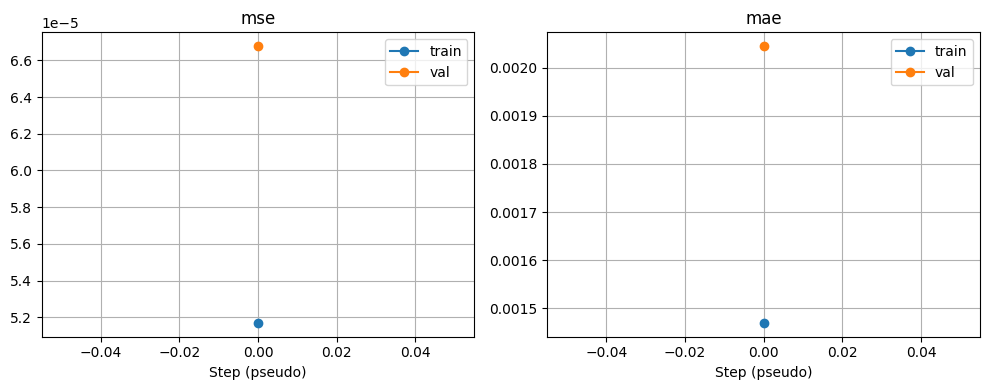

I0000 00:00:1779012848.264887   76348 service.cc:153] XLA service 0x71a25c034cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779012848.264905   76348 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1779012848.300535   76348 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779012848.430807   76348 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1779012848.439749   76348 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2142__.20
I0000 00:00:1779012848.450973   76348 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I


  Mosfet Loss Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0004     0.0004     0.0004
compile_metrics     0.0127     0.0134     0.0136


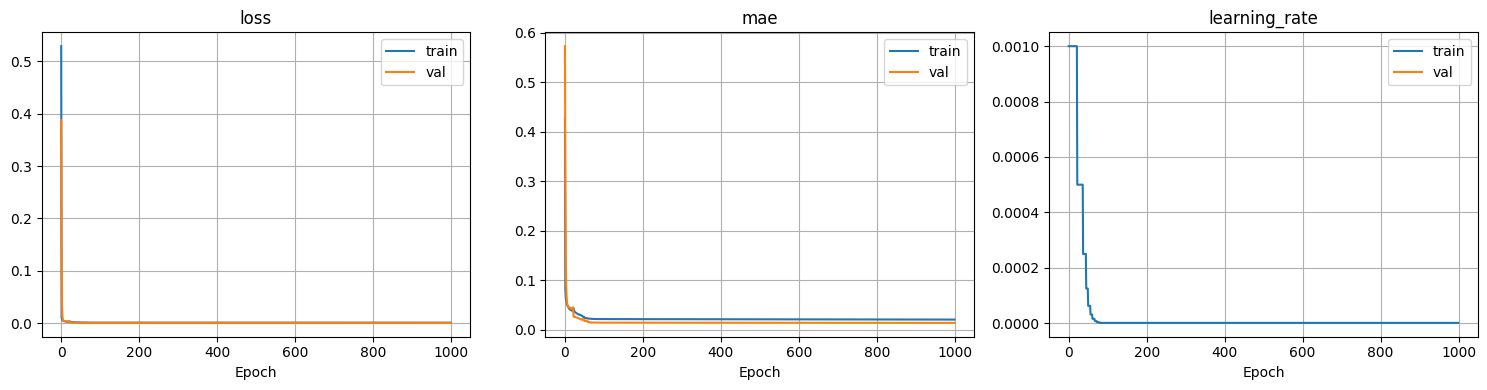

In [7]:
X = df[['L1', 'L2', 'C1', 'fs']].values

X = mc.generate_features(X)
print(f"X[0] = {X[0]}")
print(f"len(X[0]) = {len(X[0])}")
y_ripple  = df[['i_L1_ripple_rate', 'V_out_ripple_rate']].values
y_mos_loss = df[['mosfet_cond_loss', 'mosfet_switch_loss']].values

splits = mc.split_data(X, y_ripple, y_mos_loss)

X_train, X_val, X_test = splits[0]
y_ripple_train, y_ripple_val, y_ripple_test = splits[1]
y_mos_loss_train, y_mos_loss_val, y_mos_loss_test = splits[2]


# 학습용
X_train, X_val, X_test, x_scaler = mc.scale_data(
    X_train, X_val, X_test,
    scaler = StandardScaler()
)

#ripple
y_ripple_train, y_ripple_val, y_ripple_test, y_ripple_scaler = mc.scale_data(
    y_ripple_train, y_ripple_val, y_ripple_test,
    scaler = StandardScaler()
)

# mosfet loss
# y_mos_loss_train, y_mos_loss_val, y_mos_loss_test, y_mos_loss_scaler = mc.scale_data(
#     y_mos_loss_train, y_mos_loss_val, y_mos_loss_test,
#     scaler = StandardScaler()
# )
# print("var: ",y_mos_loss_scaler.var_, "\nmean:", y_mos_loss_scaler.mean_, "\nstd:", y_mos_loss_scaler.scale_)
# print(y_mos_loss_scaler) # mosfet_switch_loss minimum is 13


y_mos_loss_train = np.log1p(y_mos_loss_train)
y_mos_loss_val   = np.log1p(y_mos_loss_val)
y_mos_loss_test  = np.log1p(y_mos_loss_test)

model_mos_loss2 =  mc.build_random_forest()

model_mos_loss= mc.build_test_residual(input_dim=len(X[0]), output_dim=2, model_name="mos_loss")



history_mosfet1 = mc.train_and_evaluate_sklearn(
    model_mos_loss2,
    X_train, y_mos_loss_train,
    X_val,   y_mos_loss_val,
    X_test,  y_mos_loss_test,
    model_name='model_mos_loss2 Model',
)

history_mosfet2 = mc.train_and_evaluate(
    model_mos_loss,
    X_train, y_mos_loss_train,
    X_val,   y_mos_loss_val,
    X_test,  y_mos_loss_test,
    model_name='Mosfet Loss Model',
    epochs=1000, batch_size=64
)

In [8]:
preds = np.array([
    model_mos_loss2(X_test, training=True)  # sampling
    for _ in range(100)
])

mean = preds.mean(axis=0)
std = preds.std(axis=0)

TypeError: 'RandomForestRegressor' object is not callable

In [ ]:
# example =np.asarray([[0.000900, 1.29990e-05, 9.67904e-06, 0.000188]])
# example = mc.generate_features(example)
# example =  x_scaler.transform(example)

# non_scaled = model_mos_loss.predict(example)

# # y_pred = y_mos_loss_scaler.inverse_transform(non_scaled)      
# y_pred = np.expm1(non_scaled)

# print(non_scaled)
# print(y_pred)



# non_scaled = model_mos_loss2.predict(example)

# # y_pred = y_mos_loss_scaler.inverse_transform(non_scaled)      
# y_pred = np.expm1(non_scaled)

# print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[[2.8420513 1.7250279]]
[[16.150911   4.6126776]]
[[16.16942856  3.56427497]]


In [10]:
y = model_mos_loss.predict(np.array(X_test))

from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_orig = np.expm1(y)[:, 0]
y_true_orig = np.expm1(y_mos_loss_test)[:, 0]


abs_err = np.abs(y_true_orig - y_pred_orig)

idx = np.argmax(abs_err)

print("worst index (filtered):", idx)
print("X_test:", x_scaler.inverse_transform([X_test[idx]]))
print("y_true:", y_true_orig[idx])
print("y_pred:", y_pred_orig[idx])

mse = mean_squared_error(y_true_orig, y_pred_orig)
mae = mean_absolute_error(y_true_orig, y_pred_orig)

print("MSE:", mse)
print("MAE:", mae)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
worst index (filtered): 857
X_test: [[2.20000000e-04 2.50000000e-05 1.00000000e-06 5.56000000e+04
  4.54524794e+03 3.99840064e+04 9.90099010e+05 1.79856115e-05
  2.20000000e-10 1.39000000e+00 9.78473581e+07 7.19424455e-01
  8.79648141e+00 1.79856115e-11]]
y_true: 14.116633442800259
y_pred: 15.645084
MSE: 0.06863467278431706
MAE: 0.2080300933997425


In [ ]:
print("y_pred max:", np.max(y[:,0]))
print("y_pred min:", np.min(y[:,0]))

print("y_pred max:", np.max(y_pred_orig[:,0]))
print("y_pred min:", np.min(y_pred_orig[:,0]))

print("inf in y_pred:", np.isinf(y_pred).any())
print("inf in y_pred_orig:", np.isinf(y_pred_orig).any())

y_pred max: 6.3174205
y_pred min: 2.534407


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed